In [1]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo 
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

UCI dataset Differentiated Thyroid Cancer Recurrence (id=915)

Originally, contains 16 categorical parameters relating to the individuals' health. But after creating dummies for each (and dropping one from each category), there are 40 binary parameters.
Number of observations: 383

Target: binary (whether cancer recurred or not)



In [9]:
# fetch dataset
data_id=915
data_frame = fetch_ucirepo(id=data_id) 
  
# data (as pandas dataframes) 
X = data_frame.data.features
y = data_frame.data.targets
df = pd.concat([X, y], axis=1)
df = pd.get_dummies(df, drop_first=True, dtype=int)
df = df.to_numpy()
M = df[:, :-1]
y = df[:, -1]
num_obs, params = M.shape

Here, I replace the y-values equal to 1 with a very large (positive) number and the y-values equal to 0 with a very negative number.

In [10]:
y = np.where(y == 1, 1e20, -1e20)

In [11]:
rng=np.random.default_rng(51)

def resort_data(num_pts, num_params, M, y):
    '''
    num_pts: How many data points are needed (size of training data)
    M: Entire data matrix (including y-values)'''

    # Reorder M by observation so that logit doesn't break
    y_T = np.zeros(num_pts)
    while not np.any(y_T != y_T[0]):
        indices = rng.choice(np.arange(num_obs), size=num_pts, replace=False)
        y_T = y[indices]

    M_new = np.concatenate((M[indices, :], np.delete(M, indices, axis=0)))

    # Randomly sort parameters
    param_ordering = rng.permutation(params)
    M_new = M_new[:, param_ordering]

    # Breaking down the resorted matrix
    M_TM = M_new[:num_pts, :num_params]
    M_TU = M_new[:num_pts, num_params:]
    M_PM = M_new[num_pts:, :num_params]
    M_PU = M_new[num_pts:, num_params:]
    y_P = np.delete(y, indices)
    y_new = np.concatenate((y_T, y_P))
    return M_new, M_TM, M_TU, M_PM, M_PU, y_T, y_P, y_new

In [16]:
error_matrix = []
error_matrix_log = []

# Compute log loss (risk)
for j in range(2,num_obs,15):
    error_matrix.append([])
    error_matrix_log.append([])
    for i in range(1,params):
        listy = []
        log_listy = []
        for k in range(10):
            M_new, M_TM, M_TU, M_PM, M_PU, y_T, y_P, y_new = resort_data(j, i, M, y)
            model_params = np.linalg.lstsq(M_TM, y_T, rcond=None)[0]
            y_hat = np.concatenate((M_TM, M_PM)) @ model_params
            error = np.mean((y_new - y_hat)**2)

            y_logs = .5+np.hstack((y_new,y_hat))/2e20
            log_listy.append(log_loss(y_logs[:,0], y_logs[:,1]))
            listy.append(error)
        listy = np.array(listy)
        error_matrix[-1].append(np.mean(listy))
        error_matrix_log[-1].append(np.mean(log_listy))

error_matrix = np.array(error_matrix)
error_matrix_log = np.array(error_matrix_log)

# Clip to 95th percentile
p95 = np.percentile(error_matrix, 95)
error_matrix = np.clip(error_matrix, a_min=0, a_max=p95)

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

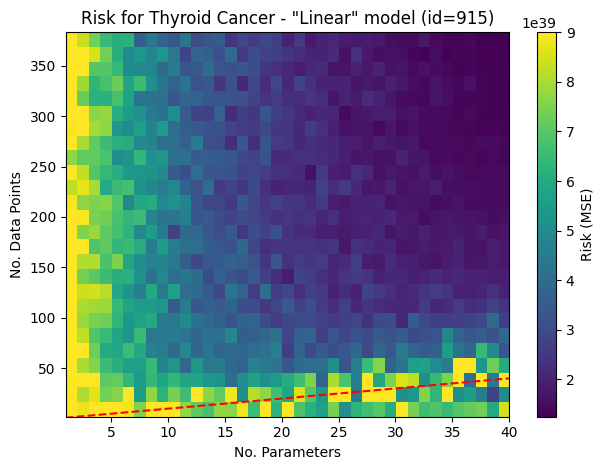

In [14]:
# Plotting it
fig, ax = plt.subplots()
yeet=ax.imshow(error_matrix, aspect='auto', origin='lower', extent = [1,params,2,num_obs])
plt.xlabel("No. Parameters")
plt.ylabel("No. Data Points")
plt.title(f'Risk for Thyroid Cancer - "Linear" model (id={data_id})')
fig.colorbar(yeet,label='Risk (MSE)')
plt.plot([1,min(num_obs,params)],[1,min(num_obs,params)],'--',color='red')
plt.ylim((2,num_obs))
plt.xlim((1,params))
plt.tight_layout()
# plt.savefig(f'logit_risk_linear_{data_id}.png',dpi=400)
plt.show()